In [65]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib as jb

In [66]:
BASE_DIR = os.path.dirname(os.getcwd())
print(BASE_DIR)

dataset_path = os.path.join(
    BASE_DIR,
    "farming ml datasets",
    "crop prediction.csv"
)
print(dataset_path)

dataset = pd.read_csv(dataset_path)

d:\ML PROJECTS\AgroAqua AI Intelligent Farming and Aquaculture Management System
d:\ML PROJECTS\AgroAqua AI Intelligent Farming and Aquaculture Management System\farming ml datasets\crop prediction.csv


In [67]:
dataset

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [68]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [69]:
print(pd.isnull(dataset).sum())

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [70]:
dataset.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [71]:
duplicates = dataset.duplicated().sum()
print(f'The number of duplicates is {duplicates}')

The number of duplicates is 0


In [72]:
dataset_shape = dataset.shape
print(f'The dataset shape is {dataset_shape}')

The dataset shape is (2200, 8)


In [73]:
dataset_object_type = dataset.dtypes
print(dataset_object_type)

N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object


In [74]:
numeric_columns =  dataset.select_dtypes(include='number').columns
print(numeric_columns)


Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'], dtype='object')


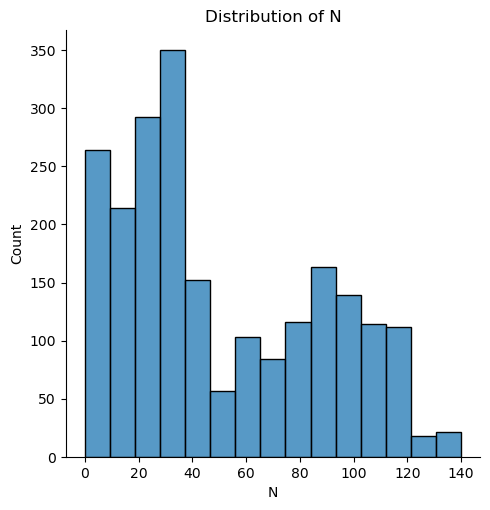

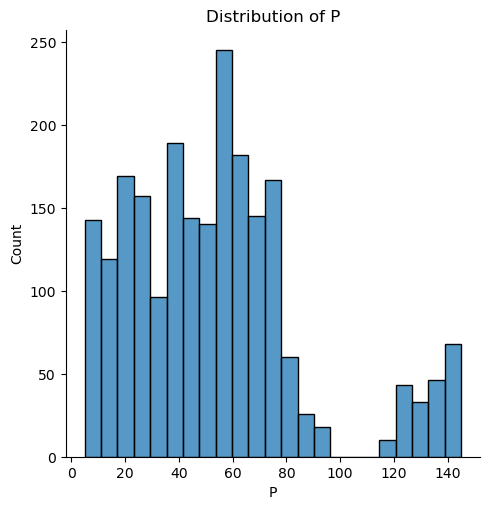

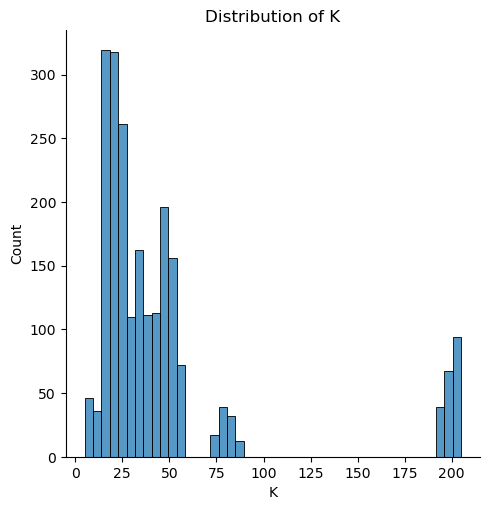

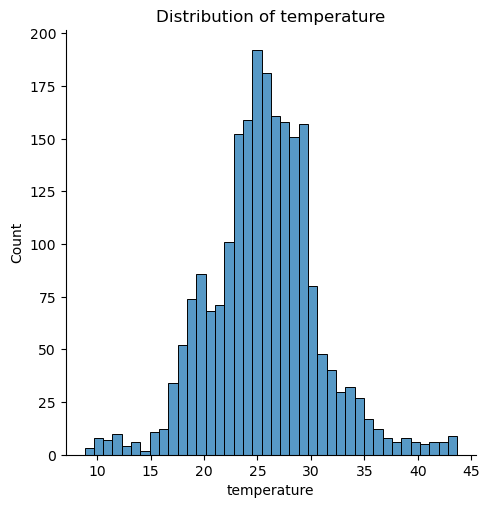

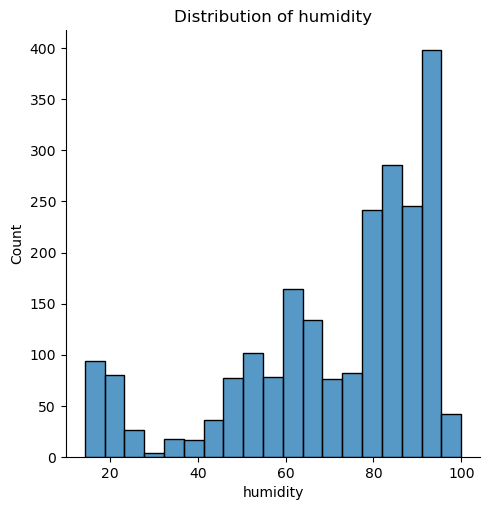

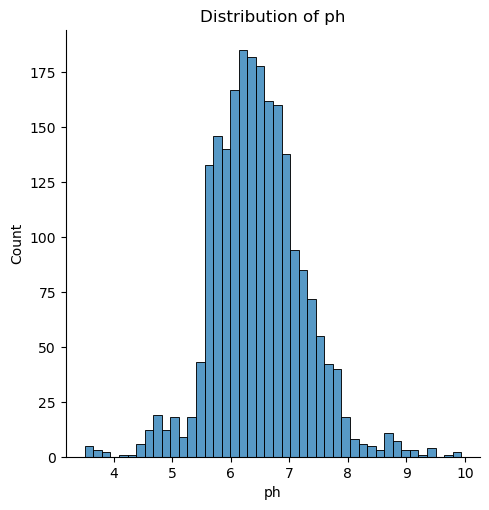

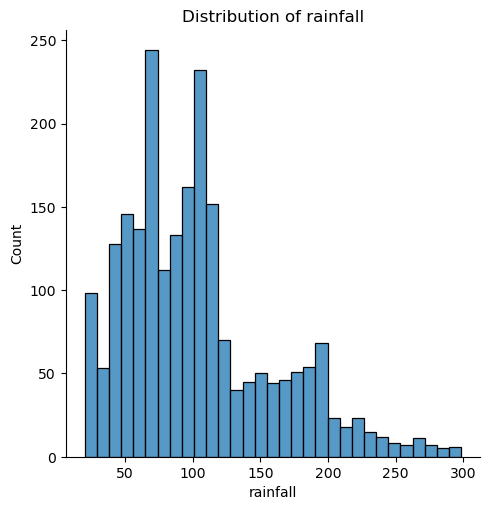

In [75]:
for col in numeric_columns:
    plt.Figure(figsize=(10,10))
    sns.displot(dataset[col])
    plt.title(f'Distribution of {col}')
    plt.show()

In [76]:
categorical_columns = dataset.select_dtypes(include='object').columns
print(categorical_columns)

Index(['label'], dtype='object')


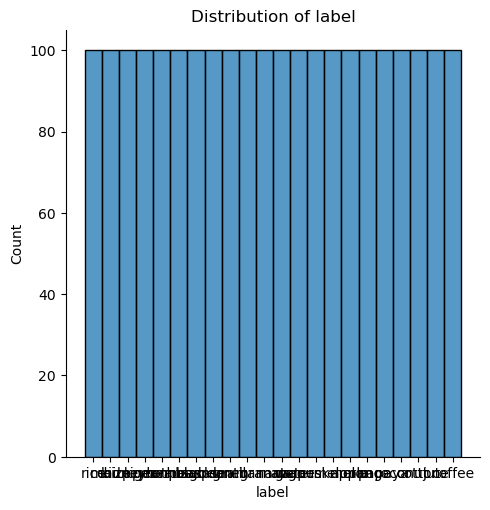

In [77]:
for col in categorical_columns:
    plt.Figure(figsize=(10,10))
    sns.displot(dataset[col])
    plt.title(f'Distribution of {col}')
    plt.show()

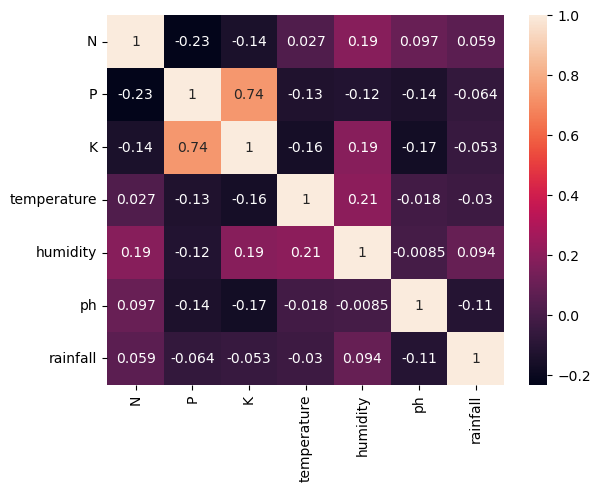

In [78]:
sns.heatmap(dataset[numeric_columns].corr(), annot=True)
plt.show()

In [79]:
x = dataset.drop('label', axis=1)

In [80]:
x

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340
...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507
2196,99,15,27,27.417112,56.636362,6.086922,127.924610
2197,118,33,30,24.131797,67.225123,6.362608,173.322839
2198,117,32,34,26.272418,52.127394,6.758793,127.175293


In [81]:
y = dataset['label']

In [82]:
y

0         rice
1         rice
2         rice
3         rice
4         rice
         ...  
2195    coffee
2196    coffee
2197    coffee
2198    coffee
2199    coffee
Name: label, Length: 2200, dtype: object

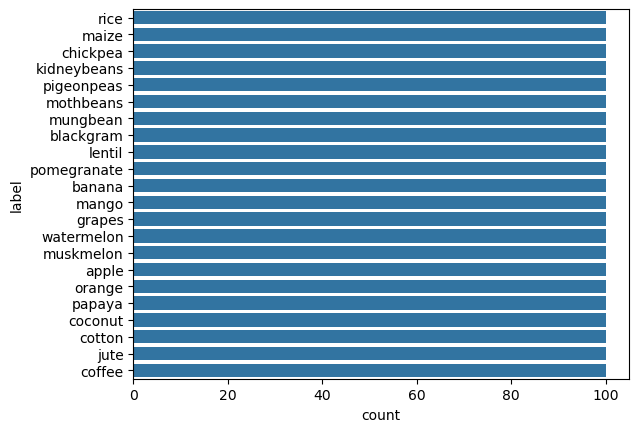

In [83]:
sns.countplot(y)
plt.show()

In [84]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [85]:
x_train

,N,P,K,temperature,humidity,ph,rainfall
1656,17,16,14,16.396243,92.181519,6.625539,102.944161
752,37,79,19,27.543848,69.347863,7.143943,69.408782
892,7,73,25,27.521856,63.132153,7.288057,45.208411
1041,101,70,48,25.360592,75.031933,6.012697,116.553145
1179,0,17,30,35.474783,47.972305,6.279134,97.790725
...,...,...,...,...,...,...,...
1638,10,5,5,21.213070,91.353492,7.817846,112.983436
1095,108,94,47,27.359116,84.546250,6.387431,90.812505
1130,11,36,31,27.920633,51.779659,6.475449,100.258567
1294,11,124,204,13.429886,80.066340,6.361141,71.400430


In [86]:
x_test

,N,P,K,temperature,humidity,ph,rainfall
1451,101,17,47,29.494014,94.729813,6.185053,26.308209
1334,98,8,51,26.179346,86.522581,6.259336,49.430510
1761,59,62,49,43.360515,93.351916,6.941497,114.778071
1735,44,60,55,34.280461,90.555616,6.825371,98.540477
1576,30,137,200,22.914300,90.704756,5.603413,118.604465
...,...,...,...,...,...,...,...
59,99,55,35,21.723831,80.238990,6.501698,277.962619
71,67,45,38,22.727910,82.170688,7.300411,260.887506
1908,121,47,16,23.605640,79.295731,7.723240,72.498009
1958,116,52,19,22.942767,75.371706,6.114526,67.080226


In [87]:
y_train

1656       orange
752     blackgram
892        lentil
1041       banana
1179        mango
          ...    
1638       orange
1095       banana
1130        mango
1294       grapes
860        lentil
Name: label, Length: 1760, dtype: object

In [88]:
y_test

1451     muskmelon
1334    watermelon
1761        papaya
1735        papaya
1576         apple
           ...    
59            rice
71            rice
1908        cotton
1958        cotton
482     pigeonpeas
Name: label, Length: 440, dtype: object

In [89]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [90]:
x_train

array([[-9.03426596e-01, -1.12616170e+00, -6.68506601e-01, ...,
         9.36586183e-01,  1.93473784e-01,  5.14970176e-03],
       [-3.67051340e-01,  7.70358846e-01, -5.70589522e-01, ...,
        -1.00470485e-01,  8.63917548e-01, -6.05290566e-01],
       [-1.17161422e+00,  5.89737842e-01, -4.53089028e-01, ...,
        -3.82774991e-01,  1.05029771e+00, -1.04580687e+00],
       ...,
       [-1.06433917e+00, -5.24091685e-01, -3.35588533e-01, ...,
        -8.98381379e-01, -6.34357580e-04, -4.37358211e-02],
       [-1.06433917e+00,  2.12501638e+00,  3.05234239e+00, ...,
         3.86340190e-01, -1.48467347e-01, -5.69036842e-01],
       [-5.01145154e-01,  7.40255346e-01, -5.11839275e-01, ...,
        -4.18045489e-01,  6.86860180e-01, -8.96531475e-01]])

In [91]:
x_test

array([[ 1.34934948, -1.0960582 , -0.02225388, ...,  1.05232434,
        -0.37619899, -1.38984486],
       [ 1.26889319, -1.36698971,  0.05607978, ...,  0.67956909,
        -0.28013033, -0.96895253],
       [ 0.22296144,  0.25859933,  0.01691295, ...,  0.98974316,
         0.60209743,  0.22056087],
       ...,
       [ 1.88572474, -0.19295318, -0.62933977, ...,  0.35134079,
         1.61311363, -0.54905776],
       [ 1.75163092, -0.04243567, -0.57058952, ...,  0.1731198 ,
        -0.46741089, -0.64767698],
       [-1.22525175,  0.43922034, -0.55100611, ..., -1.74645651,
        -0.45817577,  0.95946086]])

In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [93]:
models = {
        'Logistic Regression': LogisticRegression(random_state=42),
        'Decision Tree': DecisionTreeClassifier(criterion='entropy', random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=10, criterion = 'entropy', random_state=42),
        'SVM': SVC(kernel='rbf', random_state=42),
        'KNN': KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
    }

In [94]:
trained_models = {}
for model_name, model in models.items():
    print(f'---------- Training {model_name} --------------')
    trained_models[model_name] = model.fit(x_train, y_train)
    print('-------------------------------------------------')

---------- Training Logistic Regression --------------
-------------------------------------------------
---------- Training Decision Tree --------------
-------------------------------------------------
---------- Training Random Forest --------------
-------------------------------------------------
---------- Training SVM --------------
-------------------------------------------------
---------- Training KNN --------------
-------------------------------------------------


In [95]:
test_models = {}
for model_name, model in models.items():
    print(f'----------- Testing {model_name} ----------')
    test_models[model_name] = model.predict(x_test)
    print('------------------------------------------')

----------- Testing Logistic Regression ----------
------------------------------------------
----------- Testing Decision Tree ----------
------------------------------------------
----------- Testing Random Forest ----------
------------------------------------------
----------- Testing SVM ----------
------------------------------------------
----------- Testing KNN ----------
------------------------------------------


In [96]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

training_results = {}

for model_name, model in trained_models.items():
    y_train_pred = model.predict(x_train)
    training_results[model_name] = {
        'accuracy': accuracy_score(y_train, y_train_pred),
        'recall': recall_score(y_train, y_train_pred, average='weighted'),
        'f1': f1_score(y_train, y_train_pred, average='weighted'),
        'precision': precision_score(y_train, y_train_pred, average='weighted')
    }
for i in training_results:
    print(i, training_results[i])

Logistic Regression {'accuracy': 0.977840909090909, 'recall': 0.977840909090909, 'f1': 0.9778256898112785, 'precision': 0.9782365564647766}
Decision Tree {'accuracy': 1.0, 'recall': 1.0, 'f1': 1.0, 'precision': 1.0}
Random Forest {'accuracy': 1.0, 'recall': 1.0, 'f1': 1.0, 'precision': 1.0}
SVM {'accuracy': 0.9880681818181818, 'recall': 0.9880681818181818, 'f1': 0.9880782742330425, 'precision': 0.9891646507650266}
KNN {'accuracy': 0.9869318181818182, 'recall': 0.9869318181818182, 'f1': 0.9869253825169441, 'precision': 0.9875552680231411}


In [97]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

testing_results = {}

for model_name, model in trained_models.items():

    y_test_pred = model.predict(x_test)

    testing_results[model_name] = {
        'accuracy': accuracy_score(y_test, y_test_pred),
        'recall': recall_score(y_test, y_test_pred, average='weighted'),
        'f1': f1_score(y_test, y_test_pred, average='weighted'),
        'precision': precision_score(y_test, y_test_pred, average='weighted')
    }

for i in testing_results:
    print(i, testing_results[i])

Logistic Regression {'accuracy': 0.9636363636363636, 'recall': 0.9636363636363636, 'f1': 0.9635115059268677, 'precision': 0.9644420567548909}
Decision Tree {'accuracy': 0.9795454545454545, 'recall': 0.9795454545454545, 'f1': 0.9793786156419462, 'precision': 0.9802884615384616}
Random Forest {'accuracy': 0.990909090909091, 'recall': 0.990909090909091, 'f1': 0.9909681049626702, 'precision': 0.9919720279720279}
SVM {'accuracy': 0.9681818181818181, 'recall': 0.9681818181818181, 'f1': 0.9680271341017991, 'precision': 0.9715171192443921}
KNN {'accuracy': 0.9568181818181818, 'recall': 0.9568181818181818, 'f1': 0.9567492608232794, 'precision': 0.9628976143584398}


In [98]:
final_model = trained_models['Random Forest']

In [99]:
y_pred = final_model.predict(x_test)

In [100]:
y_pred

array(['muskmelon', 'watermelon', 'papaya', 'papaya', 'apple', 'mango',
       'apple', 'mothbeans', 'mungbean', 'lentil', 'blackgram', 'coconut',
       'pomegranate', 'jute', 'coconut', 'pomegranate', 'apple', 'maize',
       'papaya', 'muskmelon', 'coffee', 'papaya', 'orange', 'papaya',
       'chickpea', 'jute', 'mungbean', 'orange', 'pigeonpeas', 'rice',
       'pomegranate', 'mothbeans', 'jute', 'lentil', 'jute', 'blackgram',
       'jute', 'chickpea', 'chickpea', 'kidneybeans', 'papaya', 'mango',
       'blackgram', 'maize', 'mungbean', 'maize', 'pigeonpeas', 'coconut',
       'muskmelon', 'maize', 'blackgram', 'coffee', 'grapes', 'mungbean',
       'coffee', 'kidneybeans', 'cotton', 'apple', 'banana', 'blackgram',
       'watermelon', 'coconut', 'lentil', 'orange', 'papaya',
       'pigeonpeas', 'orange', 'rice', 'muskmelon', 'pigeonpeas',
       'muskmelon', 'coconut', 'jute', 'banana', 'blackgram', 'papaya',
       'banana', 'cotton', 'watermelon', 'orange', 'coffee', 'chickp

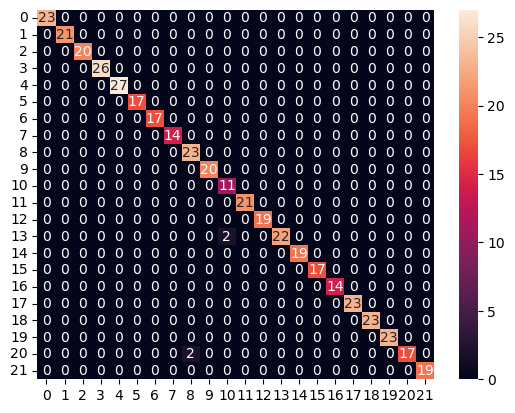

In [101]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
plt.show()

In [102]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.85      1.00      0.92        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.92      0.96        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
      papaya       1.00    

In [103]:
from sklearn.model_selection import cross_val_score
cv = cross_val_score(estimator=final_model, X=x_train, y=y_train, cv=10)
print(cv.std())
print(cv.mean())

0.009906588508046987
0.9909090909090909


In [104]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f'The accuracy of the model is {round(accuracy, 2)*100}')

The accuracy of the model is 99.0


In [105]:
best_model = trained_models['Random Forest']
jb.dump(best_model, 'crop_recommendation.joblib')
jb.dump(sc, 'crop_recommendation_scaler.joblib')

['crop_recommendation_scaler.joblib']